# Anomaly Machine Learning Model

### This script takes the data we created in the concardance scripts, merges BRCA 1 and 2, then attempts to predict Pathogenic Variants as anomalies. I used the REVEL and PloyPhen-2 classification labels created in the concordance script to test how well the model performed.

### Two Types of anomaly models were created - Isolation Forest and Local Outlier Factor

In [1]:
#importing the needed packages 
import pandas as pd
import numpy as np

In [ ]:
#uploading the data
BRCAVs = pd.read_csv("C:/Users/knigh/Documents/UHD MSDA/Capstone/ML Model/2026_BRCA1and2_ConcordanceLabels.csv")
BRCAVs.head()
#removing the data to comply with All of Us data user policies.

In [3]:
#grabbing the list of columns names for further data wrangling
BRCAVs.columns

Index(['locus', 'alleles', 'qc_AC', 'qc_AF', 'qc_AN', 'call_rate', 'n_het',
       'info_AC', 'info_AF', 'info_AN', 'vid', 'contig', 'position',
       'consequence', 'clinvar_classification', 'variant_type', 'ref_allele',
       'alt_allele', 'gvs_all_ac', 'gvs_all_an', 'gvs_all_af', 'gvs_all_sc',
       'dbsnp_rsid', 'revel', 'vid_alt', 'gvs_max_subpop', 'aa_change',
       'transcript', 'gene_symbol', 'gvs_max_ac', 'gvs_max_sc', 'gvs_max_an',
       'gnomad_max_subpop', 'protein_id', 'hgvsp', 'aa_extract', 'AA1', 'AA2',
       'Protein', 'Position', 'Ref_AA', 'Alt_AA',
       '(HumDiv) Polyphen Significance(S1)', 'Score(S1)', 'Sensitivity(S1)',
       'FPR Score(S1)', 'Specificity(S1)',
       '(HumDiv) Polyphen Significance(S2)', 'Score(S2)', 'Sensitivity(S2)',
       'FPR Score(S2)', 'Specificity(S2)', 'clinvar_CL', 'revel_CL',
       '(HumDiv) Polyphen Significance(S1)_CL',
       '(HumDiv) Polyphen Significance(S2)_CL'],
      dtype='object')

In [ ]:
#dropping un-needed columns like unique identifers, labels, redunant, and non-useful information
BRCA_MD1 = BRCAVs.drop(columns=['locus', 'alleles','vid', 'contig', 'position','consequence', 'clinvar_classification', 'variant_type','dbsnp_rsid','vid_alt', 'aa_change',
       'transcript', 'gnomad_max_subpop', 'protein_id', 'hgvsp', 'aa_extract','(HumDiv) Polyphen Significance(S1)', 'Score(S1)', 'Sensitivity(S1)','FPR Score(S1)', 
       'Specificity(S1)','(HumDiv) Polyphen Significance(S2)', 'Score(S2)', 'Sensitivity(S2)','FPR Score(S2)', 'Specificity(S2)', 'clinvar_CL', 'revel_CL',
       '(HumDiv) Polyphen Significance(S1)_CL','(HumDiv) Polyphen Significance(S2)_CL'])

BRCA_MD1.head()
#No unique idenitifers present for participant data

,qc_AC,qc_AF,qc_AN,call_rate,n_het,info_AC,info_AF,info_AN,ref_allele,alt_allele,...,gene_symbol,gvs_max_ac,gvs_max_sc,gvs_max_an,AA1,AA2,Protein,Position,Ref_AA,Alt_AA
0,"[158203, 1]","[0.999993679047306, 6.320952693990038e-06]",158204,0.999949,1,[1],[1.20537694547839e-06],829616,G,T,...,BRCA1,1,1,143702,Thr,Asn,P38398,1799,T,N
1,"[158207, 1]","[0.9999936792071198, 6.3207928802589e-06]",158208,0.999975,1,[2],[2.4107248326354284e-06],829626,C,T,...,BRCA1,1,1,51006,Val,Met,P38398,1792,V,M
2,"[158201, 3]","[0.999981037141918, 1.8962858081970115e-05]",158204,0.999949,3,[3],[3.6161482717222026e-06],829612,C,T,...,BRCA1,3,3,143700,Gly,Asp,P38398,1788,G,D
3,"[158207, 1]","[0.9999936792071198, 6.3207928802589e-06]",158208,0.999975,1,[1],[1.2053711337720885e-06],829620,C,T,...,BRCA1,1,1,143704,Cys,Tyr,P38398,1787,C,Y
4,"[158189, 3]","[0.999981035703449, 1.89642965510266e-05]",158192,0.999874,3,[3],[3.6165057321615856e-06],829530,A,T,...,BRCA1,3,3,143688,Cys,Ser,P38398,1787,C,S


## Exploring the Data

In [5]:
#looking at the meta data for the dataframe to see the data types of each variable
BRCA_MD1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1354 entries, 0 to 1353
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   qc_AC           1354 non-null   object 
 1   qc_AF           1354 non-null   object 
 2   qc_AN           1354 non-null   int64  
 3   call_rate       1354 non-null   float64
 4   n_het           1354 non-null   int64  
 5   info_AC         1354 non-null   object 
 6   info_AF         1354 non-null   object 
 7   info_AN         1354 non-null   int64  
 8   ref_allele      1354 non-null   object 
 9   alt_allele      1354 non-null   object 
 10  gvs_all_ac      1354 non-null   int64  
 11  gvs_all_an      1354 non-null   int64  
 12  gvs_all_af      1354 non-null   float64
 13  gvs_all_sc      1354 non-null   int64  
 14  revel           1354 non-null   float64
 15  gvs_max_subpop  1354 non-null   object 
 16  gene_symbol     1354 non-null   object 
 17  gvs_max_ac      1354 non-null   i

In [6]:
#looking at an overview of the numeric variables
BRCA_MD1.describe()

,qc_AN,call_rate,n_het,info_AN,gvs_all_ac,gvs_all_an,gvs_all_af,gvs_all_sc,revel,gvs_max_ac,gvs_max_sc,gvs_max_an,Position
count,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000
mean,158182.793205,0.999815,187.815362,829476.270310,1881.667651,829476.206795,0.002268,1396.242245,0.359276,288.415805,235.062038,142707.589365,1465.002954
std,118.630745,0.000750,2171.141622,638.897522,27819.153660,638.895632,0.033532,17676.143486,0.207359,3896.402846,2567.682665,107683.321617,932.380508
min,155030.000000,0.979888,0.000000,813402.000000,1.000000,813402.000000,0.000001,1.000000,0.010000,1.000000,1.000000,1610.000000,3.000000
25%,158190.000000,0.999861,1.000000,829532.000000,2.000000,829532.000000,0.000002,2.000000,0.183250,1.000000,1.000000,51008.000000,691.250000
50%,158199.000000,0.999918,2.000000,829586.000000,5.000000,829586.000000,0.000006,5.000000,0.330000,2.000000,2.000000,143694.000000,1336.500000
75%,158204.000000,0.999949,5.000000,829610.000000,21.000000,829610.000000,0.000025,21.000000,0.517000,9.750000,9.750000,143704.000000,2138.750000
max,158212.000000,1.000000,37066.000000,829660.000000,816982.000000,829660.000000,0.984719,414441.000000,0.948000,130715.000000,77105.000000,446694.000000,3417.000000


In [7]:
#looking at an overview of the object variables
BRCA_MD1.describe(include='object')

,qc_AC,qc_AF,info_AC,info_AF,ref_allele,alt_allele,gvs_max_subpop,gene_symbol,AA1,AA2,Protein,Ref_AA,Alt_AA
count,1354,1354,1354,1354,1354,1354,1354,1354,1354,1354,1354,1354,1354
unique,439,439,207,948,4,4,7,2,20,20,2,20,20
top,"[158201, 1]","[0.9999936789673961, 6.321032603886171e-06]",[1],[1.2054089108648328e-06],A,G,amr,BRCA2,Ser,Arg,P51587,S,R
freq,60,60,330,12,374,393,729,906,146,124,906,146,124


In [8]:
#looking for missing values
BRCA_MD1.isna().sum()

#No NA's, Thats great!!

qc_AC             0
qc_AF             0
qc_AN             0
call_rate         0
n_het             0
info_AC           0
info_AF           0
info_AN           0
ref_allele        0
alt_allele        0
gvs_all_ac        0
gvs_all_an        0
gvs_all_af        0
gvs_all_sc        0
revel             0
gvs_max_subpop    0
gene_symbol       0
gvs_max_ac        0
gvs_max_sc        0
gvs_max_an        0
AA1               0
AA2               0
Protein           0
Position          0
Ref_AA            0
Alt_AA            0
dtype: int64

In [9]:
#making sure no duplicate rows
BRCA_MD1.duplicated().sum()

#none, awesome!

np.int64(0)

## Transforming the variables to be model ready

### Starting with the object variables

In [10]:
#looking at the variables info_AC and info_AF, they look like numeric lists with only one value
#should be able to easily change from object to numeric by removing [ ], but need to make sure all cells contain only one value

print("info_AC count of more than 1 value in cell:\n", BRCA_MD1['info_AC'].str.count(',').value_counts())
print("info_AF count of more than 1 value in cell:\n", BRCA_MD1['info_AF'].str.count(',').value_counts())

info_AC count of more than 1 value in cell:
 info_AC
0    1354
Name: count, dtype: int64
info_AF count of more than 1 value in cell:
 info_AF
0    1354
Name: count, dtype: int64


In [11]:
#One value in each cell confirmed, changing AC and AF to numeric
BRCA_MD1['info_AC'] = BRCA_MD1['info_AC'].astype(str).str.strip('[]').astype(float)
BRCA_MD1['info_AF'] = BRCA_MD1['info_AF'].astype(str).str.strip('[]').astype(float)

BRCA_MD1[['info_AC','info_AF']].head()

,info_AC,info_AF
0,1.0,0.000001
1,2.0,0.000002
2,3.0,0.000004
3,1.0,0.000001
4,3.0,0.000004


In [12]:
#now looking at the variables qc_AC and qc_AF, they look like numeric lists with more than one value in the lists
#because the cell values are strings presenting as list, we should convert them to actual lists before manipulating the data

#ast package can safely parse a string that represents a Python literal, like a list, into the actual Python object.
import ast

#Converting the string representation of lists into actual Python lists
BRCA_MD1['qc_AC'] = BRCA_MD1['qc_AC'].apply(ast.literal_eval)
BRCA_MD1['qc_AF'] = BRCA_MD1['qc_AF'].apply(ast.literal_eval)

#checking the length of the lists to ensure they are all the same for when we split them later
print(BRCA_MD1['qc_AC'].apply(len).value_counts())
print(BRCA_MD1['qc_AF'].apply(len).value_counts())

#Both columns just have lists of 2, makes for easier splitting

qc_AC
2    1354
Name: count, dtype: int64
qc_AF
2    1354
Name: count, dtype: int64


In [13]:
#This step takes each list in the qc_AC and qc_AF columns, converts them into separate columns (Ref and Alt) by turning the lists into a DataFrame, 
#and aligns them with the original DataFrame’s index.
BRCA_MD1[['qc_AC_Ref', 'qc_AC_Alt']] = pd.DataFrame(BRCA_MD1['qc_AC'].tolist(), index=BRCA_MD1.index)
BRCA_MD1[['qc_AF_Ref', 'qc_AF_Alt']] = pd.DataFrame(BRCA_MD1['qc_AF'].tolist(), index=BRCA_MD1.index)

#Checking the values processed correctly 
BRCA_MD1[['qc_AC_Ref', 'qc_AC_Alt','qc_AF_Ref', 'qc_AF_Alt']].head()

,qc_AC_Ref,qc_AC_Alt,qc_AF_Ref,qc_AF_Alt
0,158203,1,0.999994,0.000006
1,158207,1,0.999994,0.000006
2,158201,3,0.999981,0.000019
3,158207,1,0.999994,0.000006
4,158189,3,0.999981,0.000019


In [14]:
#dropping the original qc_AC and AF cols
BRCA_MD1=BRCA_MD1.drop(columns=["qc_AC","qc_AF"])

BRCA_MD1.head()

,qc_AN,call_rate,n_het,info_AC,info_AF,info_AN,ref_allele,alt_allele,gvs_all_ac,gvs_all_an,...,AA1,AA2,Protein,Position,Ref_AA,Alt_AA,qc_AC_Ref,qc_AC_Alt,qc_AF_Ref,qc_AF_Alt
0,158204,0.999949,1,1.0,0.000001,829616,G,T,1,829616,...,Thr,Asn,P38398,1799,T,N,158203,1,0.999994,0.000006
1,158208,0.999975,1,2.0,0.000002,829626,C,T,2,829626,...,Val,Met,P38398,1792,V,M,158207,1,0.999994,0.000006
2,158204,0.999949,3,3.0,0.000004,829612,C,T,3,829612,...,Gly,Asp,P38398,1788,G,D,158201,3,0.999981,0.000019
3,158208,0.999975,1,1.0,0.000001,829620,C,T,1,829620,...,Cys,Tyr,P38398,1787,C,Y,158207,1,0.999994,0.000006
4,158192,0.999874,3,3.0,0.000004,829530,A,T,3,829530,...,Cys,Ser,P38398,1787,C,S,158189,3,0.999981,0.000019


In [15]:
#now to transform the catagorical object variables

#dropping additional variables found to be redunant
BRCA_MD1=BRCA_MD1.drop(columns=["gene_symbol","AA1","AA2"])

BRCA_MD1.head()

,qc_AN,call_rate,n_het,info_AC,info_AF,info_AN,ref_allele,alt_allele,gvs_all_ac,gvs_all_an,...,gvs_max_sc,gvs_max_an,Protein,Position,Ref_AA,Alt_AA,qc_AC_Ref,qc_AC_Alt,qc_AF_Ref,qc_AF_Alt
0,158204,0.999949,1,1.0,0.000001,829616,G,T,1,829616,...,1,143702,P38398,1799,T,N,158203,1,0.999994,0.000006
1,158208,0.999975,1,2.0,0.000002,829626,C,T,2,829626,...,1,51006,P38398,1792,V,M,158207,1,0.999994,0.000006
2,158204,0.999949,3,3.0,0.000004,829612,C,T,3,829612,...,3,143700,P38398,1788,G,D,158201,3,0.999981,0.000019
3,158208,0.999975,1,1.0,0.000001,829620,C,T,1,829620,...,1,143704,P38398,1787,C,Y,158207,1,0.999994,0.000006
4,158192,0.999874,3,3.0,0.000004,829530,A,T,3,829530,...,3,143688,P38398,1787,C,S,158189,3,0.999981,0.000019


In [16]:
#making dummy vaiables for the remaining catagorical variables

#columns that need dummy encoding
dummy_cols = ['ref_allele', 'alt_allele', 'gvs_max_subpop', 
              'Protein', 'Ref_AA', 'Alt_AA']

#creating dummy variables
BRCA_MD1 = pd.get_dummies(BRCA_MD1, columns=dummy_cols, dtype=int)

#checking the result
BRCA_MD1.head()


,qc_AN,call_rate,n_het,info_AC,info_AF,info_AN,gvs_all_ac,gvs_all_an,gvs_all_af,gvs_all_sc,...,Alt_AA_M,Alt_AA_N,Alt_AA_P,Alt_AA_Q,Alt_AA_R,Alt_AA_S,Alt_AA_T,Alt_AA_V,Alt_AA_W,Alt_AA_Y
0,158204,0.999949,1,1.0,0.000001,829616,1,829616,0.000001,1,...,0,1,0,0,0,0,0,0,0,0
1,158208,0.999975,1,2.0,0.000002,829626,2,829626,0.000002,2,...,1,0,0,0,0,0,0,0,0,0
2,158204,0.999949,3,3.0,0.000004,829612,3,829612,0.000004,3,...,0,0,0,0,0,0,0,0,0,0
3,158208,0.999975,1,1.0,0.000001,829620,1,829620,0.000001,1,...,0,0,0,0,0,0,0,0,0,1
4,158192,0.999874,3,3.0,0.000004,829530,3,829530,0.000004,3,...,0,0,0,0,0,1,0,0,0,0


In [17]:
#now all columns should be numeric
BRCA_MD1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1354 entries, 0 to 1353
Data columns (total 76 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   qc_AN               1354 non-null   int64  
 1   call_rate           1354 non-null   float64
 2   n_het               1354 non-null   int64  
 3   info_AC             1354 non-null   float64
 4   info_AF             1354 non-null   float64
 5   info_AN             1354 non-null   int64  
 6   gvs_all_ac          1354 non-null   int64  
 7   gvs_all_an          1354 non-null   int64  
 8   gvs_all_af          1354 non-null   float64
 9   gvs_all_sc          1354 non-null   int64  
 10  revel               1354 non-null   float64
 11  gvs_max_ac          1354 non-null   int64  
 12  gvs_max_sc          1354 non-null   int64  
 13  gvs_max_an          1354 non-null   int64  
 14  Position            1354 non-null   int64  
 15  qc_AC_Ref           1354 non-null   int64  
 16  qc_AC_

In [18]:
#decided to drop the AN and AC cols that have a AF column of the same group (ie. qc_an, qc_ac, qc_af)
#this reasoning is because AN and AC are used to calculate AF and will lead to redunant noise in the model

BRCA_MD1=BRCA_MD1.drop(columns=["qc_AC_Ref","qc_AC_Alt","qc_AN","info_AC","info_AN","gvs_all_ac","gvs_all_an"])

BRCA_MD1.head()

,call_rate,n_het,info_AF,gvs_all_af,gvs_all_sc,revel,gvs_max_ac,gvs_max_sc,gvs_max_an,Position,...,Alt_AA_M,Alt_AA_N,Alt_AA_P,Alt_AA_Q,Alt_AA_R,Alt_AA_S,Alt_AA_T,Alt_AA_V,Alt_AA_W,Alt_AA_Y
0,0.999949,1,0.000001,0.000001,1,0.562,1,1,143702,1799,...,0,1,0,0,0,0,0,0,0,0
1,0.999975,1,0.000002,0.000002,2,0.690,1,1,51006,1792,...,1,0,0,0,0,0,0,0,0,0
2,0.999949,3,0.000004,0.000004,3,0.862,3,3,143700,1788,...,0,0,0,0,0,0,0,0,0,0
3,0.999975,1,0.000001,0.000001,1,0.789,1,1,143704,1787,...,0,0,0,0,0,0,0,0,0,1
4,0.999874,3,0.000004,0.000004,3,0.812,3,3,143688,1787,...,0,0,0,0,0,1,0,0,0,0


In [19]:
#lastely dropping the revel column to see the affect on the isolation forest model
#I first tried with revel in the model predictions to see the difference in performace
#it did not improve the model significantly and could be considered data-leakage
BRCA_MD1 = BRCA_MD1.drop(columns=["revel"])

BRCA_MD1.head()

,call_rate,n_het,info_AF,gvs_all_af,gvs_all_sc,gvs_max_ac,gvs_max_sc,gvs_max_an,Position,qc_AF_Ref,...,Alt_AA_M,Alt_AA_N,Alt_AA_P,Alt_AA_Q,Alt_AA_R,Alt_AA_S,Alt_AA_T,Alt_AA_V,Alt_AA_W,Alt_AA_Y
0,0.999949,1,0.000001,0.000001,1,1,1,143702,1799,0.999994,...,0,1,0,0,0,0,0,0,0,0
1,0.999975,1,0.000002,0.000002,2,1,1,51006,1792,0.999994,...,1,0,0,0,0,0,0,0,0,0
2,0.999949,3,0.000004,0.000004,3,3,3,143700,1788,0.999981,...,0,0,0,0,0,0,0,0,0,0
3,0.999975,1,0.000001,0.000001,1,1,1,143704,1787,0.999994,...,0,0,0,0,0,0,0,0,0,1
4,0.999874,3,0.000004,0.000004,3,3,3,143688,1787,0.999981,...,0,0,0,0,0,1,0,0,0,0


## Creating the Isolation Forest Model

In [20]:

#installing the Pyod package
#it is one of the most comprehensive packages for detecting anomalies in multivaraite data
#!pip install pyod
from pyod.models.iforest import IForest

In [21]:
#intiate isolation forest and fit to the data
if_mod = IForest()
if_mod.fit(BRCA_MD1) 

#initial predictions of either inliers or outliers
y_train_pred =if_mod.labels_  #binary labels = (0: inliers, 1: outliers)
print(y_train_pred)

#getting the raw anomaly scores and storing in y_train_scores
y_train_scores = if_mod.decision_scores_  # raw anomaly scores
print(y_train_scores)

[0 0 0 ... 0 1 1]
[-0.02248886 -0.02136975 -0.03859907 ... -0.02588891  0.1479939
  0.00505849]


In [22]:
#Using pythresh to improve our model, without it we would have to manually guess what proportion of points are outliers. 
#PyThresh helps calculate an appropriate threshold automatically, reducing the need for guessing.

#!pip install pythresh

In [23]:
#importing the different threshold methods
from pythresh.thresholds.iqr import IQR
from pythresh.thresholds.zscore import ZSCORE
from pythresh.thresholds.hist import HIST
from pythresh.thresholds.mixmod import MIXMOD

In [24]:
#initializing the thresholds
thres_iqr = IQR()
thres_zscore = ZSCORE(factor = 2)
thres_hist = HIST(method='otsu')
thres_mixmod = MIXMOD()

#calculating the predictions with the different threshold methods
# binary labels are still (0: inliers, 1: anomalies)
y_train_pred_iqr = thres_iqr.eval(y_train_scores) 
y_train_pred_zscore = thres_zscore.eval(y_train_scores)
y_train_pred_hist = thres_hist.eval(y_train_scores)
y_train_pred_mixmod = thres_mixmod.eval(y_train_scores)

In [25]:
#I need to transform my labels into binary, right now they are either Benign or Disease Causing, but need it to be 0 or 1
#will be comparing against 2 models Revel and Polyphen
#Benign will be 0's and Disease Causing will be 1's

#mapping for labels
label_map = {"Benign": 0,"Disease Causing": 1}

#creating dataframe with both label columns converted
labels_df = BRCAVs[['revel_CL','(HumDiv) Polyphen Significance(S1)_CL']].replace(label_map)

#Renaming columns to make it clear they are binary
labels_df.columns = ["Revel_label", "Polyphen_label"]

print(labels_df.head())

   Revel_label Polyphen_label
0            0              1
1            1              0
2            1              1
3            1              1
4            1              1


C:\Users\knigh\AppData\Local\Temp\ipykernel_239204\2512151366.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  labels_df = BRCAVs[['revel_CL','(HumDiv) Polyphen Significance(S1)_CL']].replace(label_map)


In [26]:
#checking the performace of the models and the different thresholds
#importing classification_report from sklearn.metrics to see accuracy, precision, recall, etc.
from sklearn.metrics import classification_report

#creating a classificantion_report breakdown for each threshold method for the web model Revel
print("IQR thresholding for Revel\n===========================================\n")
print(classification_report(labels_df['Revel_label'], y_train_pred_iqr, target_names=['normal','anomalies']))
print("zscore thresholding for Revel\n============================================\n")
print(classification_report(labels_df['Revel_label'], y_train_pred_zscore, target_names=['normal','anomalies']))
print("hist thresholding for Revel\n=========================================\n")
print(classification_report(labels_df['Revel_label'], y_train_pred_hist, target_names=['normal','anomalies']))
print("MIXMOD thresholding for Revel\n=========================================\n")
print(classification_report(labels_df['Revel_label'], y_train_pred_mixmod, target_names=['normal','anomalies']))


IQR thresholding for Revel

              precision    recall  f1-score   support

      normal       0.91      0.96      0.94      1237
   anomalies       0.04      0.02      0.02       117

    accuracy                           0.88      1354
   macro avg       0.48      0.49      0.48      1354
weighted avg       0.84      0.88      0.86      1354

zscore thresholding for Revel

              precision    recall  f1-score   support

      normal       0.91      0.97      0.94      1237
   anomalies       0.03      0.01      0.01       117

    accuracy                           0.89      1354
   macro avg       0.47      0.49      0.48      1354
weighted avg       0.84      0.89      0.86      1354

hist thresholding for Revel

              precision    recall  f1-score   support

      normal       0.91      0.98      0.95      1237
   anomalies       0.00      0.00      0.00       117

    accuracy                           0.90      1354
   macro avg       0.46      0.49      0

In [27]:
#tried to run with Polyphen but noticed there is a Nan value, so need to remedy that to have the anomaly predictions work
labels_df['Polyphen_label'] = labels_df['Polyphen_label'].replace('Error: Malformed XML', np.nan) #changing the error variant to NAs
valid = labels_df['Polyphen_label'].notna() #pulling the labels that are not NAs

print(labels_df.head())

   Revel_label  Polyphen_label
0            0             1.0
1            1             0.0
2            1             1.0
3            1             1.0
4            1             1.0


C:\Users\knigh\AppData\Local\Temp\ipykernel_239204\2249249646.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  labels_df['Polyphen_label'] = labels_df['Polyphen_label'].replace('Error: Malformed XML', np.nan) #changing the error variant to NAs


In [28]:
#creating a classificantion_report breakdown for each threshold method for the web model Polyphen
print("IQR thresholding for Polyphen\n===========================================\n")
print(classification_report(labels_df['Polyphen_label'][valid], y_train_pred_iqr[valid], target_names=['normal','anomalies']))
print("zscore thresholding for Polyphen\n============================================\n")
print(classification_report(labels_df['Polyphen_label'][valid], y_train_pred_zscore[valid], target_names=['normal','anomalies']))
print("hist thresholding for Polyphen\n=========================================\n")
print(classification_report(labels_df['Polyphen_label'][valid], y_train_pred_hist[valid], target_names=['normal','anomalies']))
print("MIXMOD thresholding for Polyphen\n=========================================\n")
print(classification_report(labels_df['Polyphen_label'][valid], y_train_pred_mixmod[valid], target_names=['normal','anomalies']))

IQR thresholding for Polyphen

              precision    recall  f1-score   support

      normal       0.56      0.96      0.71       766
   anomalies       0.28      0.02      0.04       587

    accuracy                           0.55      1353
   macro avg       0.42      0.49      0.37      1353
weighted avg       0.44      0.55      0.42      1353

zscore thresholding for Polyphen

              precision    recall  f1-score   support

      normal       0.56      0.97      0.71       766
   anomalies       0.29      0.02      0.03       587

    accuracy                           0.56      1353
   macro avg       0.43      0.49      0.37      1353
weighted avg       0.45      0.56      0.42      1353

hist thresholding for Polyphen

              precision    recall  f1-score   support

      normal       0.56      0.98      0.72       766
   anomalies       0.36      0.01      0.03       587

    accuracy                           0.56      1353
   macro avg       0.46      0.

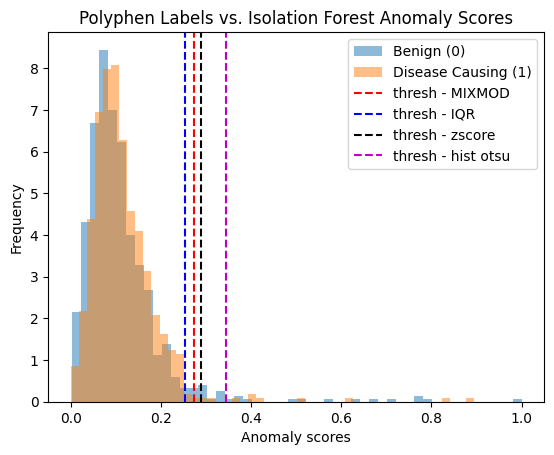

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from pythresh.thresholds.thresh_utility import normalize

#plotting the polyphen results

#Normalizing anomaly scores
normalized_anomaly_scores = normalize(y_train_scores) 

#Polyphen labels (ignore NAs)
valid = labels_df['Polyphen_label'].notna()
polyphen_labels = labels_df.loc[valid, 'Polyphen_label'].to_list()
scores_valid = [normalized_anomaly_scores[i] for i, v in enumerate(valid) if v]

#Anomaly scores for Benign (0) and Disease Causing (1)
inlier_scores = [scores_valid[i] for i, label in enumerate(polyphen_labels) if label == 0]
outlier_scores = [scores_valid[i] for i, label in enumerate(polyphen_labels) if label == 1]

#Plot histograms
plt.hist(inlier_scores, alpha=0.5, bins=50, density=True, label='Benign (0)')
plt.hist(outlier_scores, alpha=0.5, bins=50, density=True, label='Disease Causing (1)')

#Plot thresholds from different methods
plt.axvline(x=thres_mixmod.thresh_, color='r', linestyle='--', label='thresh - MIXMOD')
plt.axvline(x=thres_iqr.thresh_, color='b', linestyle='--', label='thresh - IQR')
plt.axvline(x=thres_zscore.thresh_, color='k', linestyle='--', label='thresh - zscore')
plt.axvline(x=thres_hist.thresh_, color='m', linestyle='--', label='thresh - hist otsu')

plt.xlabel("Anomaly scores")
plt.ylabel("Frequency")
plt.title("Polyphen Labels vs. Isolation Forest Anomaly Scores")
plt.legend(loc='upper right')
plt.show()

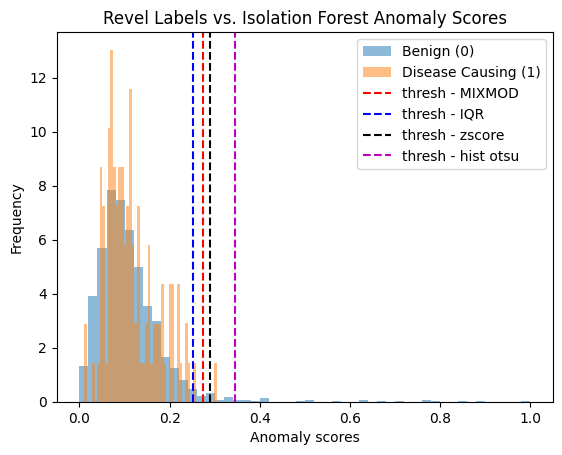

In [30]:
#plotting the revel results

#Normalizing scores
normalized_anomaly_scores = normalize(y_train_scores)

#Revel labels (No NAs)
revel_labels = labels_df['Revel_label'].to_list()

#Anomaly scores for Benign (0) and Disease Causing (1)
inlier_scores = [normalized_anomaly_scores[i] for i, label in enumerate(revel_labels) if label == 0]
outlier_scores = [normalized_anomaly_scores[i] for i, label in enumerate(revel_labels) if label == 1]

#Plot histograms
plt.hist(inlier_scores, alpha=0.5, bins=50, density=True, label='Benign (0)')
plt.hist(outlier_scores, alpha=0.5, bins=50, density=True, label='Disease Causing (1)')

#Plot thresholds from different methods
plt.axvline(x=thres_mixmod.thresh_, color='r', linestyle='--', label='thresh - MIXMOD')
plt.axvline(x=thres_iqr.thresh_, color='b', linestyle='--', label='thresh - IQR')
plt.axvline(x=thres_zscore.thresh_, color='k', linestyle='--', label='thresh - zscore')
plt.axvline(x=thres_hist.thresh_, color='m', linestyle='--', label='thresh - hist otsu')

plt.xlabel("Anomaly scores")
plt.ylabel("Frequency")
plt.legend(loc='upper right')
plt.title("Revel Labels vs. Isolation Forest Anomaly Scores")
plt.show()

## Creating the Local Outlier Factor(LOF) Model

In [31]:
#to run this model all numeric variables will need to be normalized
#most of our variables (57) are binary columns between 0 and 1
#the remaining 11 numeric variables will need to be normalized, also between 0 and 1
#we should be able to do this by min/max normalization

#importing the scaler package
from sklearn.preprocessing import MinMaxScaler

In [32]:
#making a copy dataframe to edit for the LOF model, so we can keep the original Isolation Forest df as is
BRCA_MD2 = BRCA_MD1

#looking over the columns to better select the remaining numeric ones
BRCA_MD2.columns

Index(['call_rate', 'n_het', 'info_AF', 'gvs_all_af', 'gvs_all_sc',
       'gvs_max_ac', 'gvs_max_sc', 'gvs_max_an', 'Position', 'qc_AF_Ref',
       'qc_AF_Alt', 'ref_allele_A', 'ref_allele_C', 'ref_allele_G',
       'ref_allele_T', 'alt_allele_A', 'alt_allele_C', 'alt_allele_G',
       'alt_allele_T', 'gvs_max_subpop_afr', 'gvs_max_subpop_amr',
       'gvs_max_subpop_eas', 'gvs_max_subpop_eur', 'gvs_max_subpop_mid',
       'gvs_max_subpop_oth', 'gvs_max_subpop_sas', 'Protein_P38398',
       'Protein_P51587', 'Ref_AA_A', 'Ref_AA_C', 'Ref_AA_D', 'Ref_AA_E',
       'Ref_AA_F', 'Ref_AA_G', 'Ref_AA_H', 'Ref_AA_I', 'Ref_AA_K', 'Ref_AA_L',
       'Ref_AA_M', 'Ref_AA_N', 'Ref_AA_P', 'Ref_AA_Q', 'Ref_AA_R', 'Ref_AA_S',
       'Ref_AA_T', 'Ref_AA_V', 'Ref_AA_W', 'Ref_AA_Y', 'Alt_AA_A', 'Alt_AA_C',
       'Alt_AA_D', 'Alt_AA_E', 'Alt_AA_F', 'Alt_AA_G', 'Alt_AA_H', 'Alt_AA_I',
       'Alt_AA_K', 'Alt_AA_L', 'Alt_AA_M', 'Alt_AA_N', 'Alt_AA_P', 'Alt_AA_Q',
       'Alt_AA_R', 'Alt_AA_S', 'Alt_AA_T',

In [33]:
#numeric columns to scale
numeric_cols = ['call_rate', 'n_het', 'info_AF', 'gvs_all_af', 'gvs_all_sc',
       'gvs_max_ac', 'gvs_max_sc', 'gvs_max_an', 'Position', 'qc_AF_Ref',
       'qc_AF_Alt',]

#setting the scaler to min/max and transforming the numeric variables
scaler = MinMaxScaler()
BRCA_MD2[numeric_cols] = scaler.fit_transform(BRCA_MD2[numeric_cols])

#checking everything worked properly
BRCA_MD2.head()

,call_rate,n_het,info_AF,gvs_all_af,gvs_all_sc,gvs_max_ac,gvs_max_sc,gvs_max_an,Position,qc_AF_Ref,...,Alt_AA_M,Alt_AA_N,Alt_AA_P,Alt_AA_Q,Alt_AA_R,Alt_AA_S,Alt_AA_T,Alt_AA_V,Alt_AA_W,Alt_AA_Y
0,0.997486,0.000027,4.426286e-11,0.000000,0.000000,0.000000,0.000000,0.319248,0.526069,1.000000,...,0,1,0,0,0,0,0,0,0,0
1,0.998743,0.000027,1.224098e-06,0.000001,0.000002,0.000000,0.000000,0.110981,0.524019,1.000000,...,1,0,0,0,0,0,0,0,0,0
2,0.997486,0.000081,2.448229e-06,0.000003,0.000005,0.000015,0.000026,0.319243,0.522847,0.999987,...,0,0,0,0,0,0,0,0,0,0
3,0.998743,0.000027,3.836096e-11,0.000000,0.000000,0.000000,0.000000,0.319252,0.522554,1.000000,...,0,0,0,0,0,0,0,0,0,1
4,0.993715,0.000081,2.448592e-06,0.000003,0.000005,0.000015,0.000026,0.319216,0.522554,0.999987,...,0,0,0,0,0,1,0,0,0,0


In [34]:
#checking all variables are between the range of 0 and 1
BRCA_MD2.describe() #looking at min and max

#all looks good, with a small exception of gvs_max_an having a value of a werid 1.0000000000000002, but don't expect it to affect much

,call_rate,n_het,info_AF,gvs_all_af,gvs_all_sc,gvs_max_ac,gvs_max_sc,gvs_max_an,Position,qc_AF_Ref,...,Alt_AA_M,Alt_AA_N,Alt_AA_P,Alt_AA_Q,Alt_AA_R,Alt_AA_S,Alt_AA_T,Alt_AA_V,Alt_AA_W,Alt_AA_Y
count,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,...,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000,1354.000000
mean,0.990821,0.005067,0.002302,0.002302,0.003367,0.002199,0.003036,0.317013,0.428238,0.997652,...,0.024372,0.054653,0.037666,0.025111,0.091581,0.089365,0.067208,0.084195,0.007386,0.038405
std,0.037282,0.058575,0.034053,0.034053,0.042651,0.029809,0.033302,0.241939,0.273105,0.033932,...,0.154259,0.227385,0.190458,0.156519,0.288539,0.285375,0.250475,0.277783,0.085653,0.192242
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.993086,0.000027,0.000001,0.000001,0.000002,0.000000,0.000000,0.110986,0.201596,0.999975,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.995915,0.000054,0.000005,0.000005,0.000010,0.000008,0.000013,0.319230,0.390598,0.999994,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.997486,0.000135,0.000024,0.000024,0.000048,0.000067,0.000113,0.319252,0.625586,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [35]:
#now the the data is normalized we can begin to model
#importing the LOF model from pyod
from pyod.models.lof import LOF

In [36]:
#setting up the model
lof_mod = LOF(n_neighbors=55, #nearest neighbors
              contamination=0.5) #proportion of anomalies expected

#tried with many neighbor and contamination combinations. The best recall was .62 for hist with neighbor=55, contamination=.5
#but accurarcy really suffered at 55%
#second best recall was .39 for hist with neighbor=30, contamination=.5, accuracy 65%
#highest for other thresholds was .12 for IQR and mixmod for neighbor=5 and contamination.5

#predicting with the LOF model very similar to isolation forest
y_pred_lof = lof_mod.fit(BRCA_MD2)

y_train_scores_lof = lof_mod.decision_scores_  

#setting up the thresholds again
thres_iqr = IQR()
thres_zscore = ZSCORE(factor = 2)
thres_hist = HIST(method='otsu')
thres_mixmod = MIXMOD()

#performing the predictions
y_train_pred_iqr = thres_iqr.eval(y_train_scores_lof)
y_train_pred_zscore = thres_zscore.eval(y_train_scores_lof)
y_train_pred_hist = thres_hist.eval(y_train_scores_lof)
y_train_pred_mixmod = thres_mixmod.eval(y_train_scores_lof)

#creating a classificantion_report breakdown for each threshold method for the web model Revel
#data labels should be the same
print("IQR thresholding for Revel\n===========================================\n")
print(classification_report(labels_df['Revel_label'], y_train_pred_iqr, target_names=['normal','anomalies']))
print("zscore thresholding for Revel\n============================================\n")
print(classification_report(labels_df['Revel_label'], y_train_pred_zscore, target_names=['normal','anomalies']))
print("hist thresholding for Revel\n=========================================\n")
print(classification_report(labels_df['Revel_label'], y_train_pred_hist, target_names=['normal','anomalies']))
print("MIXMOD thresholding for Revel\n=========================================\n")
print(classification_report(labels_df['Revel_label'], y_train_pred_mixmod, target_names=['normal','anomalies']))


IQR thresholding for Revel

              precision    recall  f1-score   support

      normal       0.91      1.00      0.95      1237
   anomalies       0.00      0.00      0.00       117

    accuracy                           0.91      1354
   macro avg       0.46      0.50      0.48      1354
weighted avg       0.83      0.91      0.87      1354

zscore thresholding for Revel

              precision    recall  f1-score   support

      normal       0.91      0.98      0.94      1237
   anomalies       0.10      0.03      0.04       117

    accuracy                           0.90      1354
   macro avg       0.51      0.50      0.49      1354
weighted avg       0.84      0.90      0.87      1354

hist thresholding for Revel

              precision    recall  f1-score   support

      normal       0.94      0.54      0.69      1237
   anomalies       0.11      0.62      0.19       117

    accuracy                           0.55      1354
   macro avg       0.53      0.58      0

In [37]:
#creating a classificantion_report breakdown for each threshold method for the web model Polyphen
print("IQR thresholding for Polyphen\n===========================================\n")
print(classification_report(labels_df['Polyphen_label'][valid], y_train_pred_iqr[valid], target_names=['normal','anomalies']))
print("zscore thresholding for Polyphen\n============================================\n")
print(classification_report(labels_df['Polyphen_label'][valid], y_train_pred_zscore[valid], target_names=['normal','anomalies']))
print("hist thresholding for Polyphen\n=========================================\n")
print(classification_report(labels_df['Polyphen_label'][valid], y_train_pred_hist[valid], target_names=['normal','anomalies']))
print("MIXMOD thresholding for Polyphen\n=========================================\n")
print(classification_report(labels_df['Polyphen_label'][valid], y_train_pred_mixmod[valid], target_names=['normal','anomalies']))

#highest for other thresholds was .13 for IQR and mixmod for neighbor=5 and contamination=.5
#precision was much higher for Polyphen labels with higher neigherbors. neighbor=55 and contamination = .5, all where above 40%, hist 48%

IQR thresholding for Polyphen

              precision    recall  f1-score   support

      normal       0.57      1.00      0.72       766
   anomalies       0.40      0.00      0.01       587

    accuracy                           0.57      1353
   macro avg       0.48      0.50      0.36      1353
weighted avg       0.49      0.57      0.41      1353

zscore thresholding for Polyphen

              precision    recall  f1-score   support

      normal       0.57      0.98      0.72       766
   anomalies       0.47      0.02      0.05       587

    accuracy                           0.56      1353
   macro avg       0.52      0.50      0.38      1353
weighted avg       0.52      0.56      0.43      1353

hist thresholding for Polyphen

              precision    recall  f1-score   support

      normal       0.61      0.57      0.59       766
   anomalies       0.48      0.52      0.50       587

    accuracy                           0.55      1353
   macro avg       0.54      0.

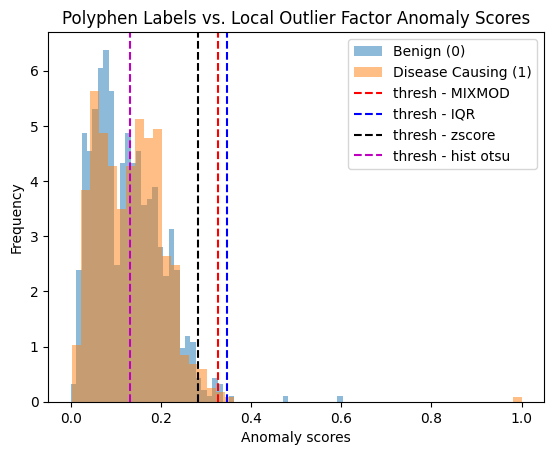

In [38]:
#plotting the polyphen results

#Normalizing anomaly scores
normalized_anomaly_scores = normalize(y_train_scores_lof) 

#Polyphen labels (ignore NAs)
valid = labels_df['Polyphen_label'].notna()
polyphen_labels = labels_df.loc[valid, 'Polyphen_label'].to_list()
scores_valid = [normalized_anomaly_scores[i] for i, v in enumerate(valid) if v]

#Anomaly scores for Benign (0) and Disease Causing (1)
inlier_scores = [scores_valid[i] for i, label in enumerate(polyphen_labels) if label == 0]
outlier_scores = [scores_valid[i] for i, label in enumerate(polyphen_labels) if label == 1]

#Plot histograms
plt.hist(inlier_scores, alpha=0.5, bins=50, density=True, label='Benign (0)')
plt.hist(outlier_scores, alpha=0.5, bins=50, density=True, label='Disease Causing (1)')

#Plot thresholds from different methods
plt.axvline(x=thres_mixmod.thresh_, color='r', linestyle='--', label='thresh - MIXMOD')
plt.axvline(x=thres_iqr.thresh_, color='b', linestyle='--', label='thresh - IQR')
plt.axvline(x=thres_zscore.thresh_, color='k', linestyle='--', label='thresh - zscore')
plt.axvline(x=thres_hist.thresh_, color='m', linestyle='--', label='thresh - hist otsu')

plt.xlabel("Anomaly scores")
plt.ylabel("Frequency")
plt.legend(loc='upper right')
plt.title("Polyphen Labels vs. Local Outlier Factor Anomaly Scores")
plt.show()

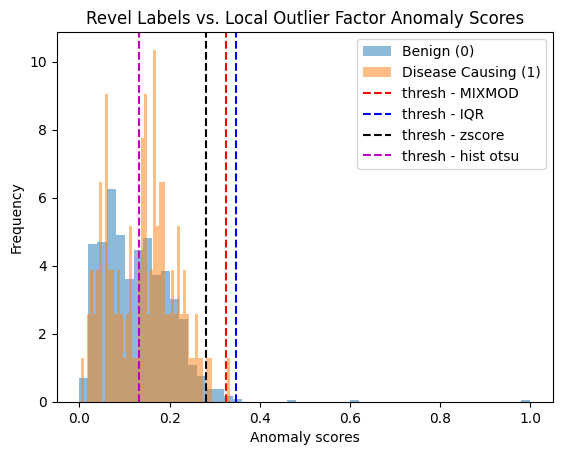

In [39]:
#plotting the revel results

#Normalizing scores
normalized_anomaly_scores = normalize(y_train_scores_lof)

#Revel labels (No NAs)
revel_labels = labels_df['Revel_label'].to_list()

#Anomaly scores for Benign (0) and Disease Causing (1)
inlier_scores = [normalized_anomaly_scores[i] for i, label in enumerate(revel_labels) if label == 0]
outlier_scores = [normalized_anomaly_scores[i] for i, label in enumerate(revel_labels) if label == 1]

#Plot histograms
plt.hist(inlier_scores, alpha=0.5, bins=50, density=True, label='Benign (0)')
plt.hist(outlier_scores, alpha=0.5, bins=50, density=True, label='Disease Causing (1)')

#Plot thresholds from different methods
plt.axvline(x=thres_mixmod.thresh_, color='r', linestyle='--', label='thresh - MIXMOD')
plt.axvline(x=thres_iqr.thresh_, color='b', linestyle='--', label='thresh - IQR')
plt.axvline(x=thres_zscore.thresh_, color='k', linestyle='--', label='thresh - zscore')
plt.axvline(x=thres_hist.thresh_, color='m', linestyle='--', label='thresh - hist otsu')

plt.xlabel("Anomaly scores")
plt.ylabel("Frequency")
plt.legend(loc='upper right')
plt.title("Revel Labels vs. Local Outlier Factor Anomaly Scores")
plt.show()